# MPhil DIS: S1 Coursework Solution 2025/26

*Nabeel Chaudary*

---
## 1) Plotting Sample Estimates
**10 marks**

### 1(i) plot total sample
- Get hold of your data sample, `sample.csv`, and make a plot of the measured energy, `E`, minus the true energy, `E_0`. This plot should be saved in `figs/Figure1.1.pdf`.

In [1]:
import pandas as pd 

# Load data 
sample_df = pd.read_csv("../sample.csv")
# Take a quick look at the data
sample_df.head()

,E_true,E_rec
0,20,20.116080
1,20,20.910469
2,20,15.256252
3,20,22.628035
4,20,25.062633


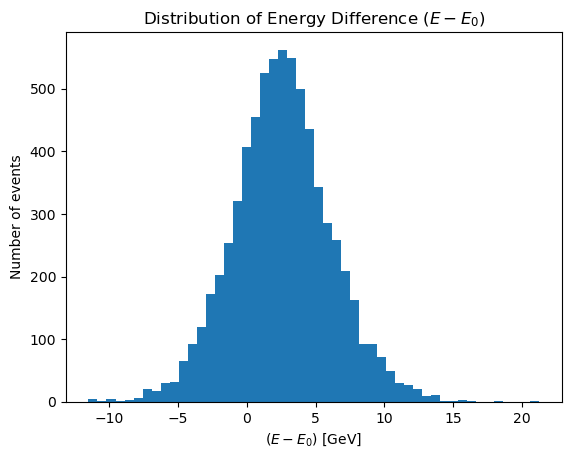

In [2]:
from s1_sol import s1plots

# Calculate the energy difference (used throughout the notebook)
sample_df["E_difference"] = sample_df["E_rec"] - sample_df["E_true"]

# Create Figure 1.1
fig, ax = s1plots.plot1_1(sample_df, bins=50)

Distribution looks roughly normal with a mean greater than 0, indicating the measured energy is on average slighlty larger than true energy.

### 1(ii) overlay samples at each $E_0$
- Make a plot which shows the distribution of `E - E_0`, with the histograms for each different value of `E_0` overlaid. This plot should be saved in `figs/Figure1.2.pdf`

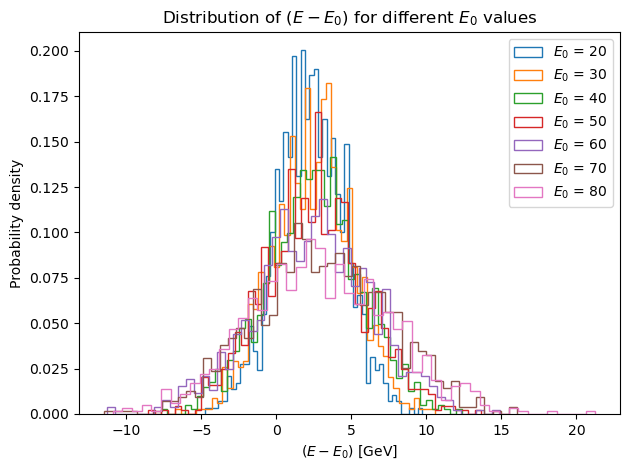

In [3]:
# Create Figure 1.2
fig, ax = s1plots.plot1_2(sample_df, bins=50)

Observations: 
 - Mean of difference is very similar for all true energy values. 
 - Means are greater than 0, indicating the measured energy is consistently greater than the true energy for all true energy values.
 - The graphs get wider and peaks get smaller for increasing true energy values. Confirms that sigma has a dependence on true energy.

### 1(iii) sample estimates
- Produce sample estimates of the mean, $\hat{\mu}_{\rm samp}$, and standard deviation, $\hat{\sigma}_{\rm samp}$, of $E$ at each value of $E_0$. These should be presented along with sample estimates of the error on these estimates (i.e. the standard error on the mean and the standard error on the standard deviation).
- Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$. This figure should be saved to `figs/Figure1.3.pdf`

The following formulas were used:

**Sample Mean:**
$$ \hat{\mu}_{samp} = \frac{1}{N} \sum_{i=1}^N E_i $$

**Sample Standard Deviation (Unbiased):**
$$ \hat{\sigma}_{samp} = \sqrt{\frac{1}{N-1} \sum_{i=1}^N (E_i - \hat{\mu}_{samp})^2} $$

**Standard Errors:**  

For sample mean:
$$ \frac{\hat{\sigma}_{samp}}{\sqrt{N}} $$

For sample standard deviation:
$$ \frac{\hat{\sigma}_{samp}}{\sqrt{2(N-1)}} $$

In [4]:
from s1_sol import s1funcs

# Calculate the sample estimates for the mean and standard deviation at each E0 value
summary = s1funcs.sample_est(sample_df)

# View the summary dataframe of the results
print(summary)

   E_true     N     mu_est    mu_err  sigma_est  sigma_err
0      20  1000  22.238933  0.070714   2.236165   0.050027
1      30  1000  32.392305  0.083746   2.648283   0.059247
2      40  1000  42.475490  0.099857   3.157760   0.070645
3      50  1000  52.509953  0.105668   3.341508   0.074756
4      60  1000  62.455090  0.122229   3.865221   0.086472
5      70  1000  72.999077  0.139147   4.400211   0.098441
6      80  1000  82.872887  0.148277   4.688922   0.104900


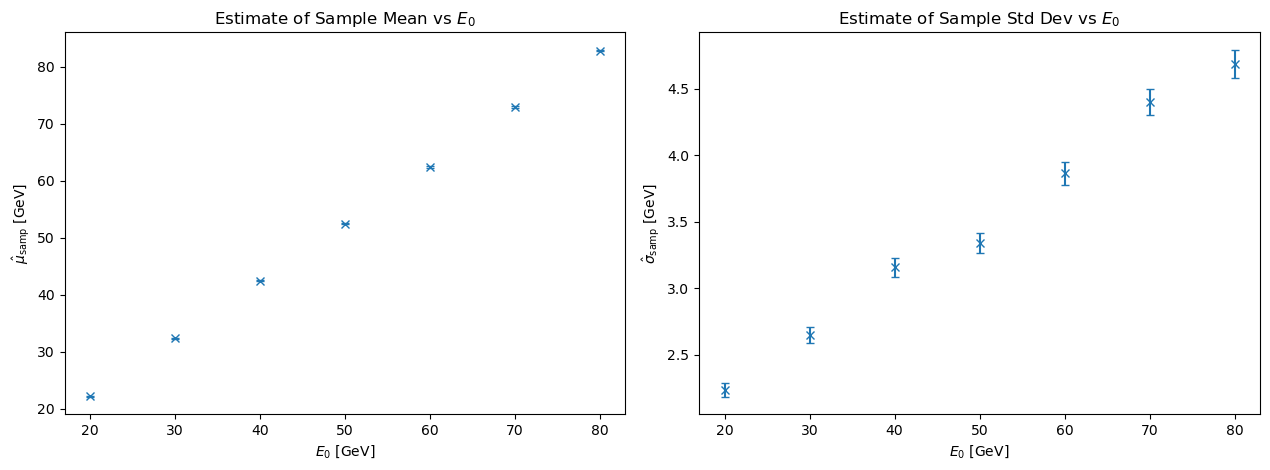

In [5]:
# Create Figure 1.3
fig, ax = s1plots.plot1_3(summary)

Observations: 
- Standard errors are relatively very small on the sample mean estimates (making it difficult to see on the plot).
- Sample mean for a given true energy is slightly higher than the true energy value.
- Both sample standard deviation and sample mean increase roughly linearly for increasing true energy.


### 1(iv) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly into the `results.json` file
- The previously made plots don't have a particular sensible y-scale. Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$ **but this time realign the y-scale** so that you plot $\hat{\mu}_{\rm samp} - E_0$ and $\hat{\sigma}_{\rm samp} / E_0$. You should also **overlay the fitted curves** and add error bands ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure1.4.pdf`

 Mean:

$$
\mu_E = \lambda E_0 + \Delta,
$$

Width, $\sigma_E$, given by:

$$
\left( \frac{\sigma_E}{E_0} \right)^2 = \left( \frac{a}{\sqrt{E_0}} \right)^2 + \left( \frac{b}{E_0} \right)^2 + c^2.
$$


**Methodology:**
1. Defined the above models for mean and width (note: for width I rearranged the above fromula to make $\sigma_E$ the subject).
2. Used the iminunit leastsquares cost function with the calculated estimate values from the previous part for each of the two models.
3. Ran the Minuit minimisation for both, with the limits and starting guesses defined below to get the best-fit parameters along with their erros.

**For mean energy fit:**

Limits used: sigma > 0 

initial guesses: lb=1.0, dE=0.0

**For the width fit:**

Limits used: a > 0, b > 0, c > 0

initial guesses: a=0.3, b=1.0, c=0.05

In [6]:
# Perform least-squares fits to the sample estimates to get estimates of the parameters,
# along with their errors 
# and the covariance matrices which will be needed later for bootstrapping
(
    lb_samp,     lb_err_samp,
    dE_samp,     dE_err_samp,
    a_samp,      a_err_samp,
    b_samp,      b_err_samp,
    c_samp,      c_err_samp,
    cov_mu_samp,
    cov_sigma_samp
) = s1funcs.fit_sample_method(summary)

# Print the fit results
print("mean energy fit results:")
print(f"lb = {lb_samp} ± {lb_err_samp}")
print(f"dE  = {dE_samp} ± {dE_err_samp}")

print("\nwidth fit results:")
print(f"a = {a_samp} ± {a_err_samp}")
print(f"b = {b_samp} ± {b_err_samp}")
print(f"c = {c_samp} ± {c_err_samp}")

#make the json file to store results
s1funcs.make_results_json("../results.json")

# Write values into results.json file
s1funcs.update_results_json("sample_ests",
                   lb_samp, lb_err_samp,
                   dE_samp, dE_err_samp,
                   a_samp, a_err_samp,
                   b_samp, b_err_samp,
                   c_samp, c_err_samp)


mean energy fit results:
lb = 1.010460635512803 ± 0.0020032194966868033
dE  = 2.0367340813210384 ± 0.08909814336609022

width fit results:
a = 0.3311289282321541 ± 0.07375506969499945
b = 1.4600771765416116 ± 0.30746566696358446
c = 0.04206377432077324 ± 0.0066761000456178055
Updated 'sample_ests' in results.json


**Methology of error bands:**

The ($\pm 1\sigma$) error bands were added to the curves by parametric bootstrapping.

After fitting the mean and width models, we take the best-fit parameters and their covariance matrices and run a bootstrap:

1. Randomly sample N new parameter sets from a multivariate normal centered on the best-fit values (using the covariances) - random parameter sets are drawn for each model (mean and width) separately. 
2. For each sample, evaluate the fitted curves.
3. At each $E_0$, take the standard deviation of the bootstrap curves. This gives error bands for the mean and width plots.


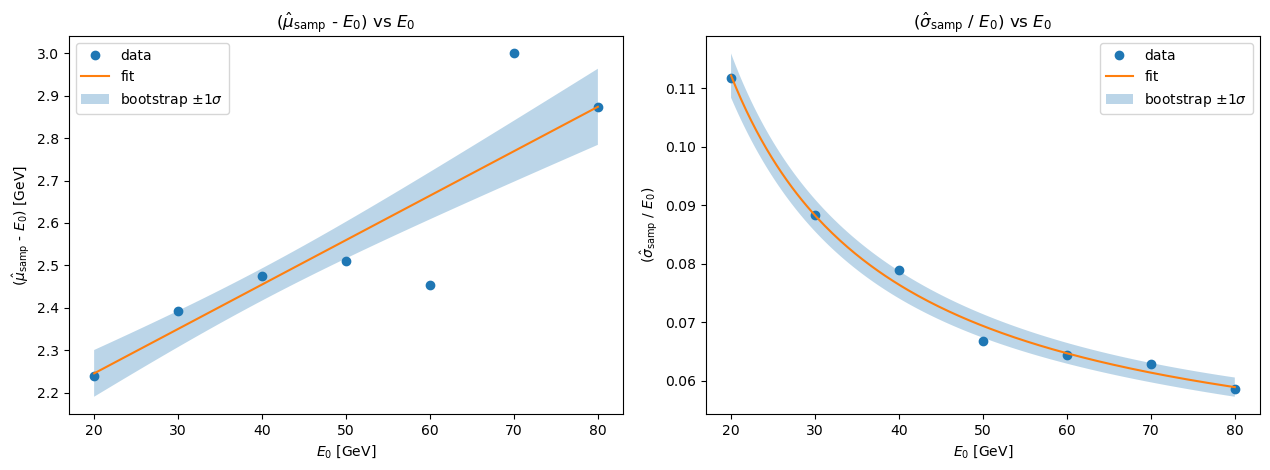

In [7]:
fig, ax = s1plots.plot1_4(
    summary,
    lb_samp, dE_samp,
    a_samp, b_samp, c_samp,
    cov_mu_samp, cov_sigma_samp,
    N_BOOT=1000, random_state=30    #Set bootstrap parameters
)

I have only included error bands and not error bars on both plots, because the sources of these two errors are the same.

Given the equations for mu and sigma (defined above), the trends in both plots behave as expected. There is some scatter around the 50-70GeV range for the mean plot (left). However, the fitted trend remains consistent with the data and the model within the error bands. 

Observatoins:
- Left plot: overall linear behaviour and the difference is always positive. 
- Right plot: data points sit well within the bands and the trend fits well with the wdith model. ($\hat{\sigma}_{\rm samp} / E_0$) decreases as $E_0$ increases, eventually leveling off.

---
## 2) Individual Fits
**10 marks**

### 2(i) normal fits
- Now instead of sample estimates for the mean and width, perform and unbinned maximum likelihood fit of the distribution of $E$ at each value of $E_0$ using a normal distribution to determine the mean, $\hat{\mu}_{\rm indiv}$, and width, $\hat{\sigma}_{\rm indiv}$, (as well as their errors) at each $E_0$
- Make two plots (sub-axes of the same figure). The left should show the distribution of $E-E_0$ (with the distribution at each value of $E_0$ overlaid) also overlaying the result of the normal likelihood fits. The right should show the distribution of $E - E_0$ for all values and then overlay the approproiately normalised sum of sub-distributions. This plot should be saved in `figs/Figure2.1.pdf`

The normal PDF for each individual fit is defined by:

$$
f(E; \mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(E - \mu)^2}{2\sigma^2} \right)
$$

**Methodology:**
1. For each $E_0$, modelled $E$ with the above Normal PDF.
2. Passed this to the `UnbinnedNLL` iminuit function which constructs the negative log likelihood. 
3. Minimized the NLL using `Minuit` with the limits and initial guesses stated below.
4. Repeated the procedure independently for each $E_0$.

Limits used: sigma > 0, mu > 0

Initial guesses: mu = sample mean of data, sigma = standard deviation of the data

In [8]:
# Get individual ML values for each E0 value
indiv_summary = s1funcs.indiv_MLsummary(sample_df)

print(indiv_summary)

   E_true     mu_est    mu_err  sigma_est  sigma_err
0      20  22.238933  0.070678   2.235046   0.049976
1      30  32.392305  0.083704   2.646958   0.059187
2      40  42.475490  0.099807   3.156180   0.070574
3      50  52.509953  0.105615   3.339837   0.074680
4      60  62.455090  0.122168   3.863288   0.086385
5      70  72.999077  0.139077   4.398011   0.098342
6      80  82.872887  0.148203   4.686577   0.104794


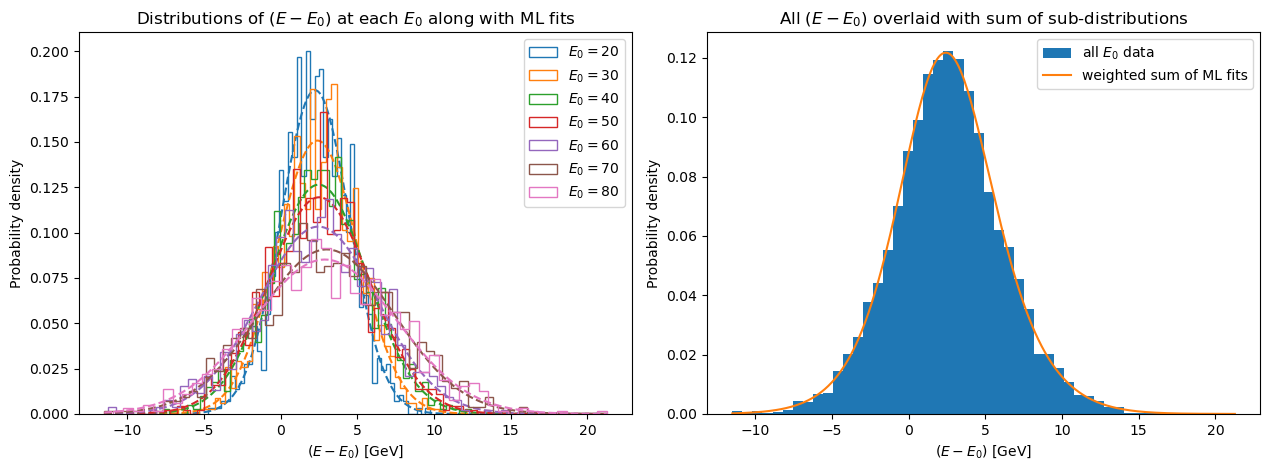

In [9]:
#Create plots
fig, ax = s1plots.plot2_1(sample_df, indiv_summary)

Observations: 
 - Plots show that the normal model is a good fit for the dataset

### 2(ii) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted values $\hat{\mu}_{\rm indiv} - E_0$ and $\hat{\sigma}_{\rm indiv}/E_0$ as a function of $E_0$ **as well as** the fitted curves. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure2.2.pdf`

This fit is the same as in part 1(iv), so refer there for details on methodoloy. See below for limits and initial guesses used - both of which have been kept consistent with part 1(iv).

**For mean energy fit:**

Limits used: sigma > 0 

initial guesses: lb=1.0, dE=0.0

**For the width fit:**

Limits used: a > 0, b > 0, c > 0

initial guesses: a=0.3, b=1.0, c=0.05

In [10]:
from s1_sol import s1funcs

# Perform least-squares fits to the individual ML estimates to get estimates of the parameters, along with their errors 
# and get the covariance matrices which will be needed later for bootstrapping
(
    lb_indiv,     lb_err_indiv,
    dE_indiv,     dE_err_indiv,
    a_indiv,      a_err_indiv,
    b_indiv,      b_err_indiv,
    c_indiv,      c_err_indiv,
    cov_mu_indiv,
    cov_sigma_indiv
) = s1funcs.fit_sample_method(indiv_summary)

# Print the fit results
print("mean energy fit results:")
print(f"lb = {lb_indiv} ± {lb_err_indiv}")
print(f"dE  = {dE_indiv} ± {dE_err_indiv}")

print("\n width fit results:")
print(f"a = {a_indiv} ± {a_err_indiv}")
print(f"b = {b_indiv} ± {b_err_indiv}")
print(f"c = {c_indiv} ± {c_err_indiv}")

# Write values into results.json file
s1funcs.update_results_json("individual_fits",
                   lb_indiv, lb_err_indiv,
                   dE_indiv, dE_err_indiv,
                   a_indiv, a_err_indiv,
                   b_indiv, b_err_indiv,
                   c_indiv, c_err_indiv)


mean energy fit results:
lb = 1.0104606344015608 ± 0.0020022325654571738
dE  = 2.036734161824791 ± 0.08905437294284371

 width fit results:
a = 0.33072503377129014 ± 0.07345483411943465
b = 1.4603980342711123 ± 0.30582267621296744
c = 0.04206373413310227 ± 0.00664178612695332
Updated 'individual_fits' in results.json


Results agree extremely well with sample estimate method.

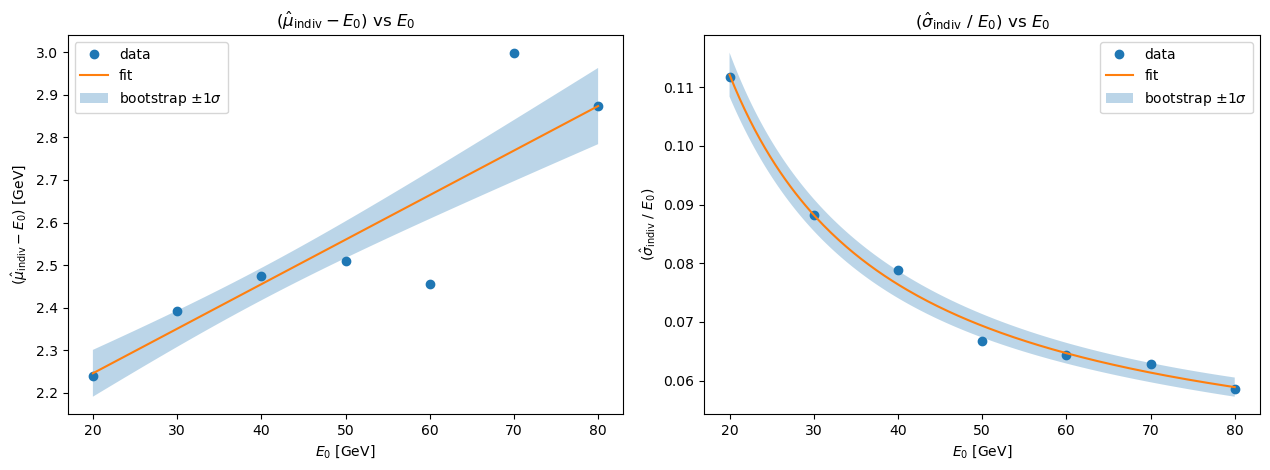

In [11]:
# Create Figure 2.2 
fig, ax = s1plots.plot2_2(
    indiv_summary,
    lb_indiv, dE_indiv,
    a_indiv, b_indiv, c_indiv,
    cov_mu_indiv, cov_sigma_indiv,
    N_BOOT=1000, random_state=30   #Set bootstrap parameters
)

I have only included error bands and not error bars on both plots, because the sources of these two errors are the same.

The methodology used to get the error bands are the same as in part 1(iv).

Plots agree extremely well with sample estimate method.

---
## 3.) Simultaneous Fit
**10 marks**

### 3(i) the simultaneous likelihood
- Write down an equation for the simultaneous likelihood in which all points are fitted together, i.e. directly fitting the sample for $\lambda$, $\Delta$, $a$, $b$ and $c$
- Appropriately code this and perform an unbinned maximum likelihood fit to all $E_0$ bins simultaneously, to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted curves for $\mu_E$ and $\sigma_E$ as a function of $E_0$. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. You should stick to the convention of plotting $\mu_E - E_0$ and $\sigma_E / E_0$ as a function of $E_0$. This figure should be saved to `figs/Figure3.1.pdf`

The simultaneous likelihood is

$$
L(\lambda,\Delta,a,b,c)
=
\prod_{i=1}^{N}
\frac{1}{\sqrt{2\pi}\,\sigma_i}
\exp\left[
-\frac{\big(E_i - (\lambda E_{0,i} + \Delta)\big)^2}{2\sigma_i^2}
\right].
$$

Where the width for event i is

$$
\sigma_i = E_{0,i} \sqrt{
\left(\frac{a}{\sqrt{E_{0,i}}}\right)^2
+ \left(\frac{b}{E_{0,i}}\right)^2
+ c^2 }.
$$


**Methodology:**
1. Modelled $E$ with the Normal PDF using the simultaneous model (which is simply the simulataneous likelihood function defined above, but without the product operator).
2. Passed this to the `UnbinnedNLL` `iminuit` function which constructs the negative log likelihood.
3. Minimized the NLL using `Minuit` with the limits and initial guesses stated below.
4. Performed the fit once over the full dataset, simultaneously across all $E_0$.


Limits used: lb > 0, a > 0, b > 0, c > 0

Initial guesses: lb=1.0,
        dE=0.0,
        a=0.3,
        b=1.0,
        c=0.05

In [12]:
# Perform simultaneous unbinned ML fit to get estimates of the parameters, along with their errors
# and get the covariance matrix which will be needed later for bootstrapping
(
    lb_sim,   lb_err,
    dE_sim, dE_err,
    a_sim,     a_err,
    b_sim,     b_err,
    c_sim,     c_err,
    sim_covariance
) = s1funcs.simultaneous_ML_fit(sample_df)

# Print the fit results
print("Simultaneous unbinned ML fit results")
print(f"lb = {lb_sim} ± {lb_err}")
print(f"dE  = {dE_sim} ± {dE_err}")
print(f"a      = {a_sim} ± {a_err}")
print(f"b      = {b_sim} ± {b_err}")
print(f"c      = {c_sim} ± {c_err}")


# save results in json
s1funcs.update_results_json(
    "simultaneous_fit",
    lb_sim,   lb_err,
    dE_sim, dE_err,
    a_sim,     a_err,
    b_sim,     b_err,
    c_sim,     c_err,
)

Simultaneous unbinned ML fit results
lb = 1.010548123795457 ± 0.0020039334082004867
dE  = 2.03486076010641 ± 0.08909185515524481
a      = 0.338580609551969 ± 0.06722832036594484
b      = 1.427781498100066 ± 0.29510937188527575
c      = 0.04153960106539567 ± 0.0062919754634062075
Updated 'simultaneous_fit' in results.json


Results agree well with the other two methods. 

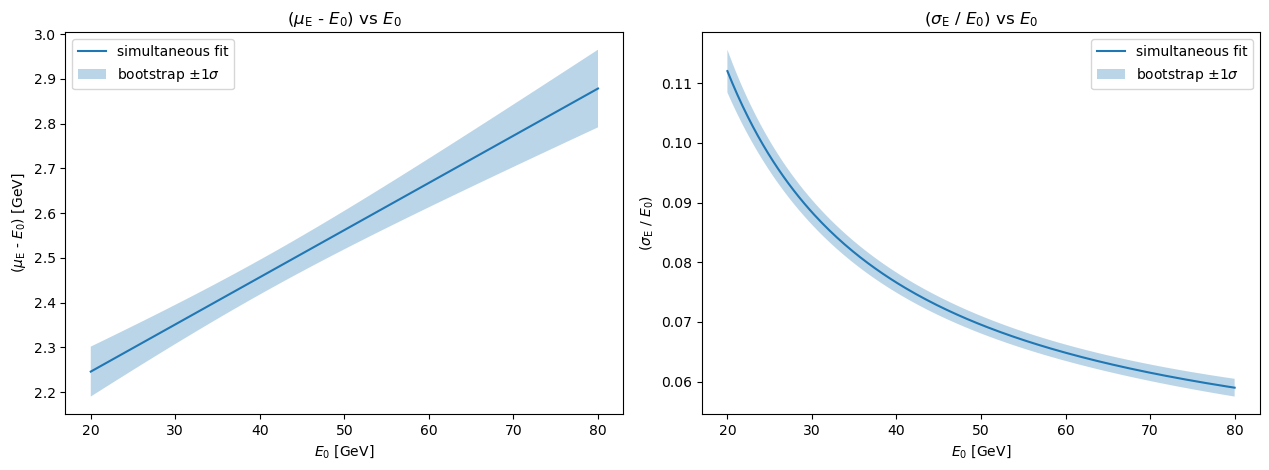

In [13]:
fig, ax = s1plots.plot3_1(
    sample_df,
    lb_sim, dE_sim,
    a_sim, b_sim, c_sim,
    sim_covariance,
    N_BOOT=500, random_state=30
)

The parametric bootstrapping methodology for the error bands for the most part is the same as in part 1(iv) - with the key difference being that here I sample all five parameters jointly from the full covariance matrix.

### 3(ii) saving the results
- At this point you should have estimates of the five parameters, $\{\lambda, \Delta, a, b, c\}$, (along with their errors), using three different methods: "a sample estimate", "individual fits" and "a simultaneous fit".
- Ensure these are now saved into the `results.json` file in the correct format

I saved the results into the results.json file as I went along, so here I am simply loading the results from the file after a bit of processing for a clean table.

In [14]:
# Load and format data in results.json into a table
df_results = s1funcs.load_results_table()
# Print the results table
print(df_results)

          method parameter     value     error
0         sample        lb  1.010461  0.002003
1         sample        dE  2.036734  0.089098
2         sample         a  0.331129  0.073755
3         sample         b  1.460077  0.307466
4         sample         c  0.042064  0.006676
5     individual        lb  1.010461  0.002002
6     individual        dE  2.036734  0.089054
7     individual         a  0.330725  0.073455
8     individual         b  1.460398  0.305823
9     individual         c  0.042064  0.006642
10  simultaneous        lb  1.010548  0.002004
11  simultaneous        dE  2.034861  0.089092
12  simultaneous         a  0.338581  0.067228
13  simultaneous         b  1.427781  0.295109
14  simultaneous         c  0.041540  0.006292


### 3(iii) comparing the results
- Make a plot which shows the estimate and error of each parameter, labelling the different estimation types with different colours.
- The parameters may well have rather different values so you will need to think carefully about how you present this information in a sensible way.
- You should save this in a file called `figs/Figure3.2.pdf`

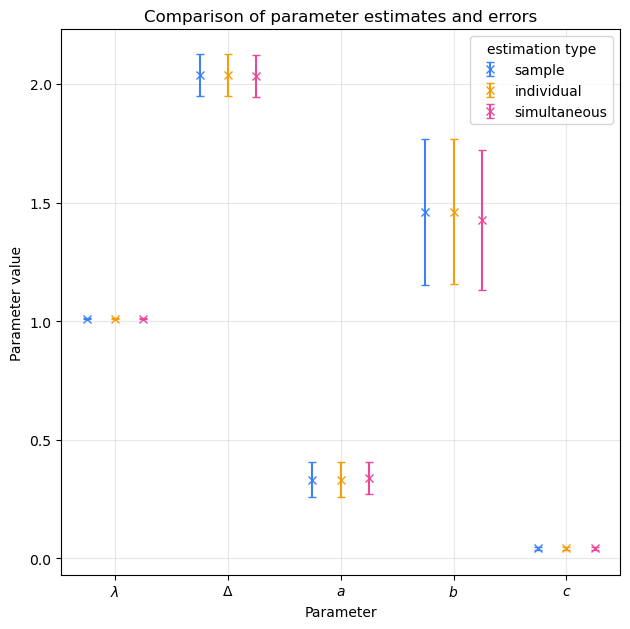

In [15]:
# Create Figure 3.2
fig, ax = s1plots.plot3_2(df_results)


Note: The parameters are in different units.

Observations:
 - All methods agree very well with each other. 
 - Sample estimate and individual fit are almost identical.
 - Simulataneous fit produced lower errors in comparison. 

See Section 5 for a more detailed discussion 

---
## 4.) Bootstrap entire sample
**20 marks**
- Run a non-parameteric bootstrap on the entire analysis using sampling with replacement (and 2500 samples). For reference on my machine this takes ~1 min)
- Produce a figure with 5 subfigures which shows histograms of the bootstrapped values with each method overlaid as a separate colour. You should save this plot in a file called `figs/Figure4.1.pdf`
- Produce a second figure which is the same in style to the plot produced in 3(iii) above this time using the bootstrapped sample to estimate the value and error. You should overlay both sets of points (i.e. the values and errors from parts 1-3 and also the bootstrapped values and errors from part 4). You should save this plot in a file called `figs/Figure4.2.pdf`

**Methodology:**

The bootstrap procedure consists of 2500 samples. For each sample:

1. Draw sample by resampling observations with replacement from the original dataset.
2. Apply all three estimation methods to this bootstrap sample.
3. Store the resulting parameter estimates from each method.

We then obtain 2500 bootstrap replicas of each parameter for each method. The mean and standard deviation of these bootstrap distributions provide estimates of the parameter values and their errors.

In [16]:

boot_df = s1funcs.run_bootstrap_all_methods(
    sample_df, 
    N_BOOT=2500, random_state=30 #Set bootstrap parameters
    )


print(boot_df)


             method parameter     value
0            sample        lb  1.008410
1            sample        lb  1.011246
2            sample        lb  1.009154
3            sample        lb  1.008310
4            sample        lb  1.006911
...             ...       ...       ...
37495  simultaneous         c  0.054339
37496  simultaneous         c  0.049083
37497  simultaneous         c  0.040398
37498  simultaneous         c  0.033053
37499  simultaneous         c  0.024591

[37500 rows x 3 columns]


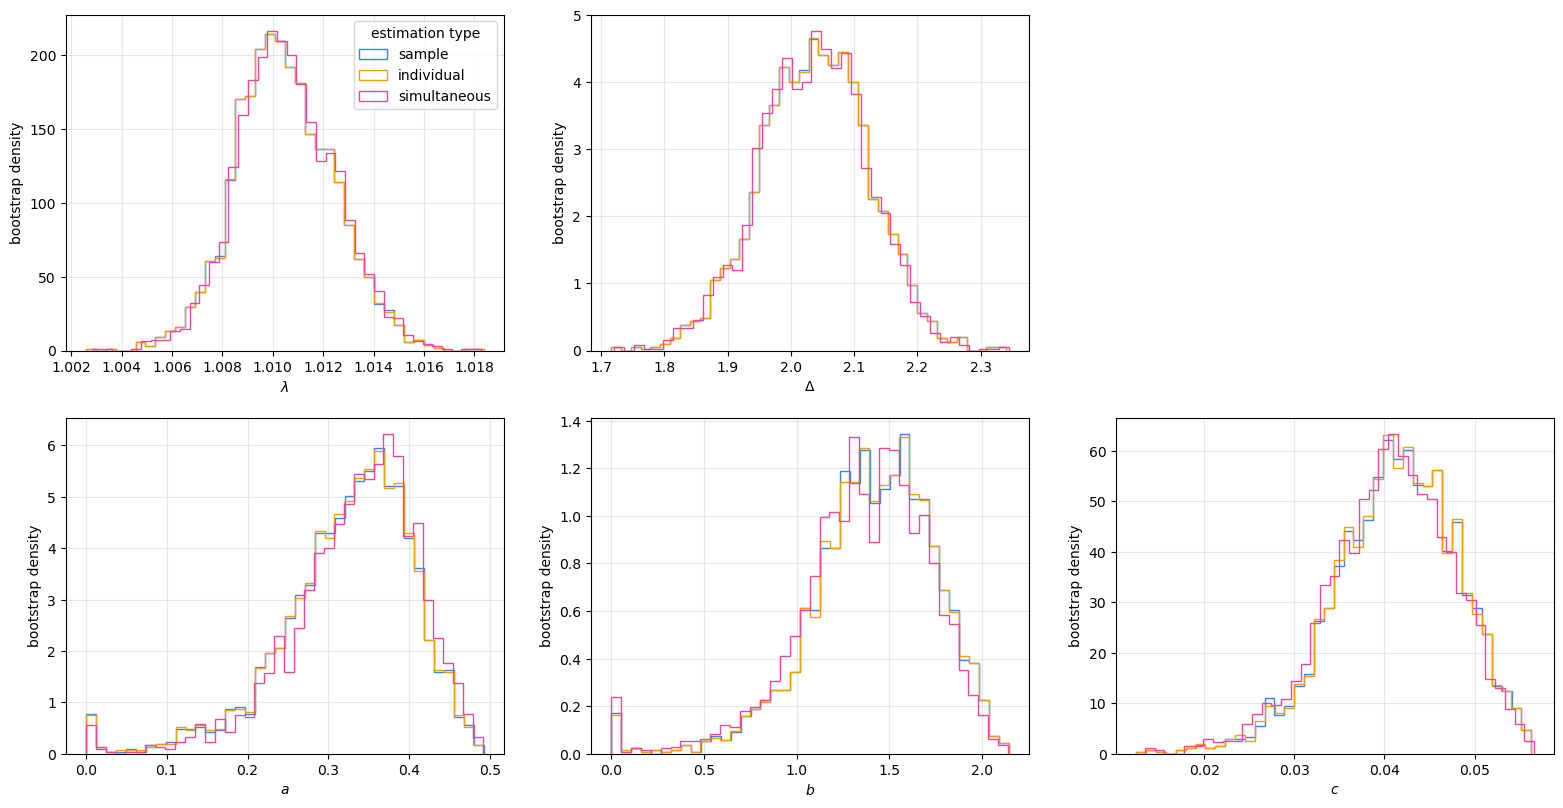

In [17]:
# Create Figure 4.1
fig, ax = s1plots.plot4_1(boot_df)


Observations:
 - lb and dE plots look relatively like a normal distribtuion 
 - Plots for a, b, and c look less so. All three have longer tails on the left side compared to the right side. 
 - Plots for a and b have a small spike just above 0.

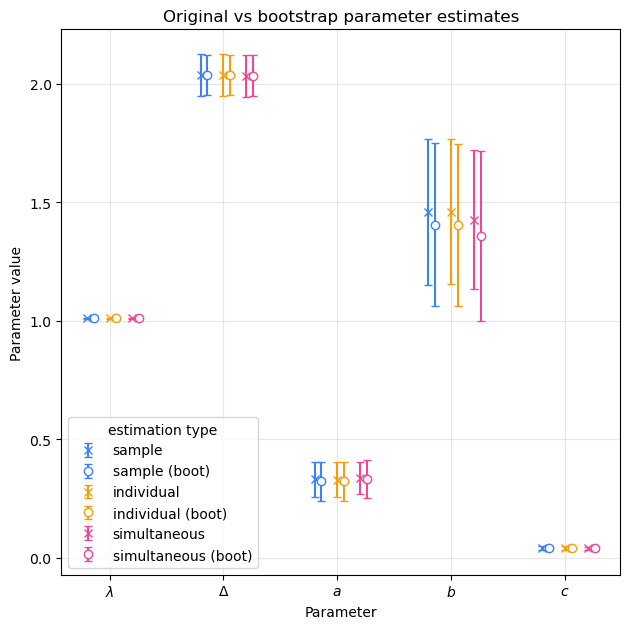

In [18]:
fig, ax = s1plots.plot4_2(boot_df, df_results)


Note: On the scales used, the error bars for λ and c are very small, so they’re hard to see on the plot. Also, the parameters are in different units.

See section 5 for a detailed discussion on results.

---
## 5.) Discussion of Results
**20 marks**

- Please briefly discuss your findings in no more than 500 words. Do you find what you would naively expect? Can you comment on any discrepancies you see? Would you redesign the analysis in any way?

All three methods we used give almost the same values for $lb$, $dE$, $a$, $b$ and $c$, with overlapping error bars (see Fig. 3.2). The histograms of $E_{\rm rec}$ and $E_{\rm rec} - E_0$ (Fig. 1.1–1.2) look roughly Gaussian with a consistent positive shift but no strong non-Gaussian tails, so modelling $E_{\rm rec}$ at fixed $E_0$ as normal seems reasonable. Naively, I would expect $lb = 1$ (unit slope) and $dE = 0$ (zero offset), so that $E_{\rm rec} \approx E_0$. Instead we find $lb \approx 1.01$ and $dE \approx 2.0$ with very small uncertainties, as seen in Fig. 1.4 (left), along with a bit of scatter around the 50-70 GeV range (although not too signifcant). So, the response is essentially linear but with a slope slightly above 1 and a constant positive offset across the whole energy range that was measured.

For the width I would expect, based on the model, $\sigma/E_0$ to decrease with $E_0$ and then converge for increasing $E_0$, as a and b terms dominate at low $E_0$ while the constant term $c$ dominates at high $E_0$. This is what we see: at low $E_0$ the fitted $a$ and $b$ terms give a ratio of about $0.1$, while by the highest energies the curve has flattened close to the constant term $c$ at about $0.05$–$0.06$, matching the $\sigma/E_0$ trend in Fig. 1.4 (right).

For a Gaussian, the maximum likelihood estimate of the mean in each $E_0$ bin is just the sample mean, so we expected the first two methods to agree very well on $lb$ and $dE$. The simultaneous fit uses the same assumptions on all events at once, so its estimates of $lb$ and $dE$ also come out very close, with any differences in $a$, $b$ and $c$ between methods are well within the quoted uncertainties. It also gives the smallest error bars, especially for $a$, $b$ and $c$, because it fits a single global likelihood accounting for correlations between the five parameters.

The bootstrap histograms for $lb$ and $dE$ (Fig. 4.1) look close to normal and are centred on the original estimates, which supports our quoted uncertainties. In contrast, the bootstrap distributions for $a$ and $b$ look slightly off, with skewed shapes and small spikes near zero (although $c$ looks normal). This suggests that, while the overall shape of the width model is well determined, the detailed split into the $1/\sqrt{E_0}$ and $1/E_0$ terms are less so. $a$ and $b$ can trade off against each other without changing $\sigma(E_0)$ very much, which explains the bootstrap graphs for them. Because of this, I would keep the basic analysis but either simplify the width model (e.g. dropping one of $a$ or $b$) or extend the $E_0$ range so that the different terms separate more clearly and the individual parameters become more interpretable.